In [46]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import sys
import os
sys.path.insert(0, os.path.abspath('../../src/'))
# Utility to make plots look nice
from kea.utils.plotting import modify_latex_rc, make_ax_step, pretty_axes
from kea.utils import binning
modify_latex_rc()
modify_latex_rc()

# Use the GPU for computing the SF, ACF, and performing Gaussian convolutions
from kea.utils import set_calculation_mode, set_fitting_mode
set_calculation_mode(use_cpu=False, use_gpu=True)
set_fitting_mode(finite_differences=True)

from kea.simulator import make_multifractal_field, make_field

# Set number of grid points
N = 100_000
# Number of dimensions (two-dimensional)
D = 1
# We have the same number of grid points in each dimension
grid_dims = (N,)

field_mono = make_field(grid_dims,
    spectrum_kwargs={'powerlaw': -5./3., 'cutoff_scale': 5.},
    spectrum_function='cutoff_powerlaw', normalize_output=True)

# Make the field
field_multi = make_multifractal_field(grid_dims,
    gauss_spectrum_kwargs={'powerlaw': -(float(D) + 1.), 'cutoff_scale': 5.},
    gauss_spectrum_function='cutoff_powerlaw',
    scaling = 0.95,
    spectrum_kwargs={'powerlaw': -5./3., 'cutoff_scale': 5.},
    spectrum_function='cutoff_powerlaw',
    seeds=(1,2,3), normalize_output=True)

Set statistic function calculation flags: (<CalculationMode.USE_GPU: 1>,)


In [47]:
from kea.utils import geometry
geometry.DEFAULT_PHYS_SCALE = 2.*np.pi

In [ ]:
from kea.statistics.statfunc import structure_function
from kea.statistics.spectra import esf_integrated_spectrum
from kea.utils import geometry

dx, dk = geometry.get_dxdk(grid_dims)
lags_mono, sfs_mono = structure_function(field_mono, orders=(1,2,3,4,5,6,7,8))
lags_multi, sfs_multi = structure_function(field_multi, orders=(1,2,3,4,5,6,7,8))

<>:71: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:74: SyntaxWarning: "\z" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\z"? A raw string is also an option.
<>:71: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:74: SyntaxWarning: "\z" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\z"? A raw string is also an option.
/tmp/ipykernel_34125/507664335.py:71: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  axs['B'].set_xlabel('Lag, $\ell/\Delta x$')
/tmp/ipykernel_34125/507664335.py:74: SyntaxWarning: "\z" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\z"? 

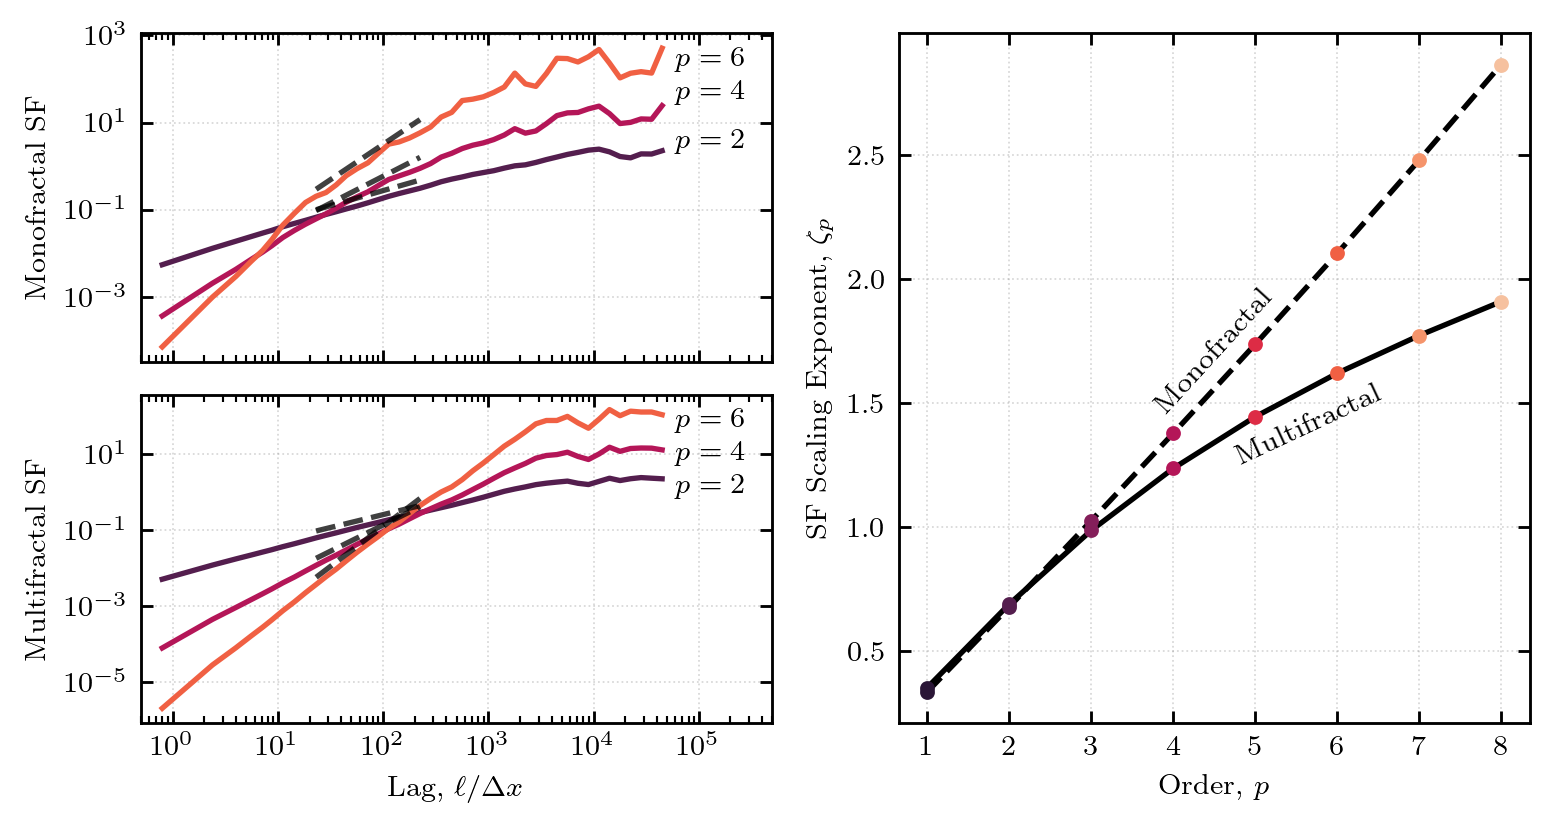

In [122]:
# fig, ax = plt.subplots(1, 2, figsize=(7., 3.5), dpi=256)

grid = '''
AACC
BBCC
'''
fig, axs = plt.subplot_mosaic(grid, dpi=256, figsize=(7., 3.5))

import seaborn as sns
cols = sns.color_palette("rocket", n_colors=len((1,2,3,4,5,6,7,8)))

pows_mono = []
pows_multi = []
from kea.utils import fitting

for i in range(len((1,2,3,4,5,6,7,8))):
    ell_b, sf_b, _ = binning.bin_data(lags_mono[:,0]*dx[0], sfs_mono[:,i], 
        min_bin=dx[0]-dx[0]/2., max_bin=geometry.DEFAULT_PHYS_SCALE/2., bin_func=np.nanmean, cut_excess=True, nan_small=False, ignore_nan=True, log_space=True, bin_loc='center',
        num_bins=50)
    if i in [1,3,5]:
        axs['B'].plot(ell_b/dx[0], sf_b, color=cols[i], label='$p=%s$' % str(i+1))

    pow, amp = np.polyfit(np.log(ell_b[9:19]), np.log(sf_b[9:19]), deg=1)
    # ax[0].loglog(ell_b[9:20], 5.*np.exp(amp)*ell_b[9:20]**pow, linestyle='--')
    pows_mono.append(pow)
    axs['C'].scatter(i+1, pow, color=cols[i], marker='o', s=10, zorder=5)
    if i in [1,3,5]:
        axs['B'].loglog(ell_b[9:20]/dx[0], 1.5*np.exp(amp)*ell_b[9:20]**pow, linestyle='--', alpha=0.75, color='black', zorder=5)

    ell_b, sf_b, _ = binning.bin_data(lags_multi[:,0]*dx[0], sfs_multi[:,i], 
        min_bin=dx[0]-dx[0]/2., max_bin=geometry.DEFAULT_PHYS_SCALE/2., bin_func=np.nanmean, cut_excess=True, nan_small=False, ignore_nan=True, log_space=True, bin_loc='center',
        num_bins=50)
    if i in [1,3,5]:
        axs['A'].plot(ell_b/dx[0], sf_b, color=cols[i], linestyle='-', zorder=2)

    pow, amp = np.polyfit(np.log(ell_b[9:19]), np.log(sf_b[9:19]), deg=1)
    # ax[0].loglog(ell_b[9:20], 5.*np.exp(amp)*ell_b[9:20]**pow, linestyle='--')
    if i in [1,3,5]:
        axs['A'].loglog(ell_b[9:20]/dx[0], 1.5*np.exp(amp)*ell_b[9:20]**pow, linestyle='--', alpha=0.75, color='black', zorder=5)

    pows_multi.append(pow)
    axs['C'].scatter(i+1, pow, color=cols[i], marker='o', s=10, zorder=5)

axs['C'].plot(np.arange(1,9), np.array(pows_mono), color='black', linestyle='--', label='Monofractal')
axs['C'].plot(np.arange(1,9), np.array(pows_multi), color='black', linestyle='-', label='Multifractal')

# axs['C'].legend(fancybox=False, edgecolor='black')

axs['C'].text(0.5, 0.45, 'Monofractal', transform=axs['C'].transAxes, ha='center', rotation=47.5)

axs['C'].text(0.65, 0.375, 'Multifractal', transform=axs['C'].transAxes, ha='center', rotation=25)

axs['B'].text(0.9, 0.7, '$p=2$', transform=axs['B'].transAxes, ha='center', rotation=0)
axs['B'].text(0.9, 0.8, '$p=4$', transform=axs['B'].transAxes, ha='center', rotation=0)
axs['B'].text(0.9, 0.9, '$p=6$', transform=axs['B'].transAxes, ha='center', rotation=0)
axs['B'].set_xlim((5e-1, 5e5))

axs['A'].text(0.9, 0.65, '$p=2$', transform=axs['A'].transAxes, ha='center', rotation=0)
axs['A'].text(0.9, 0.8, '$p=4$', transform=axs['A'].transAxes, ha='center', rotation=0)
axs['A'].text(0.9, 0.9, '$p=6$', transform=axs['A'].transAxes, ha='center', rotation=0)
axs['A'].set_xlim((5e-1, 5e5))

axs['A'].loglog()
axs['B'].loglog()
# axs['B'].legend(fancybox=False, loc='lower right', edgecolor='black')
for axx in [axs['A'], axs['B'], axs['C']]:
    pretty_axes(axx)
axs['A'].set_xticklabels([])
# ax[1].set_xscale('log')

axs['B'].set_xlabel('Lag, $\ell/\Delta x$')
axs['B'].set_ylabel('Multifractal SF')
axs['A'].set_ylabel('Monofractal SF')
axs['C'].set_ylabel('SF Scaling Exponent, $\zeta_p$')
axs['C'].set_xlabel('Order, $p$')
axs['C'].set_xticks([1,2,3,4,5,6,7,8])

fig.subplots_adjust(wspace=0.5, hspace=0.1)
fig.savefig('SF_scaling.png', pad_inches=0.1, bbox_inches='tight')